In [1]:
from datasets import load_dataset

train = load_dataset("Heliosoph/Jigsaw-Toxic-Comments", data_files="train.csv.gz", split="train")
print(train[0])

C:\Users\RTX 2050\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'id': '0000997932d777bf', 'comment_text': "Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27", 'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = train.to_pandas()

# Understanding Data

In [4]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
df.sample(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
102941,26e9b317b7145acd,"""\n\n Blocked \n\nYour repeated warnings and c...",0,0,0,0,0,0
70002,bb48c22ea4e71ef9,"""\n\n = To administrator Tawker = \n\n"""""""" \n\...",0,0,0,0,0,0
147970,4497391c524b8206,Created bare bones outline. Will flesh out lat...,0,0,0,0,0,0
93545,fa191abe5ac222d2,"No Wolfkeeper, it's you that is wrong.",0,0,0,0,0,0
76539,ccec7aa1fc6a6224,"Shipping \n\nYes, whoever added that line to t...",0,0,0,0,0,0
104959,3180383b926cc0f6,"Ping! \n\nHello again, ... it's been a few mo...",0,0,0,0,0,0
158630,f0e87d72d2889b83,RE: Your comments \n\nI am concerned about wha...,0,0,0,0,0,0
117771,75220bb08d1c4710,"""::Boing! said Zebedee - It is off course a gr...",0,0,0,0,0,0
101979,21c1ea05a4c5993f,"""\nNot that it's worthwhile to drag this out, ...",0,0,0,0,0,0
123970,971aae9e23d827fc,"""\nAnd my wikiblues continue... I just spent s...",0,0,0,0,0,0


In [6]:
df.shape

(159571, 8)

In [7]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [8]:
df.dtypes

id                 str
comment_text       str
toxic            int64
severe_toxic     int64
obscene          int64
threat           int64
insult           int64
identity_hate    int64
dtype: object

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Defining Labels

In [11]:
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

X = df["comment_text"]
y = df[label_columns]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

y.head()

Input shape: (159571,)
Target shape: (159571, 6)


,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


# Exploratory Data Analysis

In [12]:
label_counts = pd.DataFrame({
    "Yes": y.sum(),
    "No": (y == 0).sum()
})

label_counts["Yes_Percentage"] = (
    label_counts["Yes"] / len(y) * 100
).round(2)

label_counts

,Yes,No,Yes_Percentage
toxic,15294,144277,9.58
severe_toxic,1595,157976,1.00
obscene,8449,151122,5.29
threat,478,159093,0.30
insult,7877,151694,4.94
identity_hate,1405,158166,0.88


In [13]:
import matplotlib.pyplot as plt

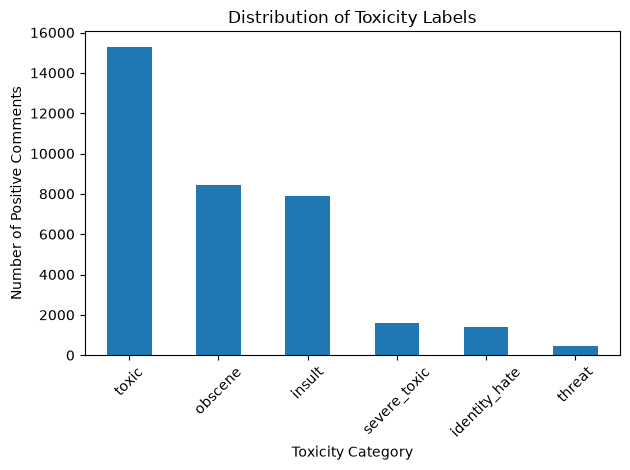

In [14]:
label_counts['Yes'].sort_values(ascending=False).plot(kind='bar')
plt.title("Distribution of Toxicity Labels")
plt.xlabel("Toxicity Category")
plt.ylabel("Number of Positive Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Counting comments with at least one toxic label

A comment may have multiple positive labels, so summing the six label columns does not tell us how many unique comments are toxic.

In [15]:
has_toxic_label=y.sum(axis=1)>0 #sums values in a row
print("Comments with at least one positive label:", has_toxic_label.sum())
print("Comments with all labels zero:", (~has_toxic_label).sum())
print("Total comments:", len(y))

Comments with at least one positive label: 16225
Comments with all labels zero: 143346
Total comments: 159571


## Examine label co-occurrence

Each cell shows the number of comments that have both the corresponding row label and column label. The diagonal shows the total positive examples for each label.

In [16]:
co_occurrence = y.T.dot(y)
co_occurrence

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


# Text exploration and preprocessing

Before training our model, we need to understand what the text looks like and decide how to prepare it for machine learning.

We'll do this in three parts:

1. Explore comment examples and their lengths.

2. Check missing and unusual text values.

3. Learn which preprocessing operations are useful for TF-IDF.

## Examine some comments

In [17]:
df[["comment_text"] + label_columns].head(10)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,alignment on this subject and which are contra...,0,0,0,0,0,0


In [18]:
df[df["toxic"] == 1]["comment_text"].head(5)

6          COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12    Hey... what is it..\n@ | talk .\nWhat is it......
16    Bye! \n\nDon't look, come or think of comming ...
42    You are gay or antisemmitian? \n\nArchangel WH...
43             FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!
Name: comment_text, dtype: str

In [19]:
df[(y.sum(axis=1) == 0)]["comment_text"].head(5)

0    Explanation\nWhy the edits made under my usern...
1    D'aww! He matches this background colour I'm s...
2    Hey man, I'm really not trying to edit war. It...
3    "\nMore\nI can't make any real suggestions on ...
4    You, sir, are my hero. Any chance you remember...
Name: comment_text, dtype: str

## Analyze comment lengths

In [20]:
df["char_length"] = df["comment_text"].str.len()
df["word_count"] = df["comment_text"].str.split().str.len()
df[["comment_text", "char_length", "word_count"]].head()

,comment_text,char_length,word_count
0,Explanation\nWhy the edits made under my usern...,264,43
1,D'aww! He matches this background colour I'm s...,112,17
2,"Hey man, I'm really not trying to edit war. It...",233,42
3,"""\nMore\nI can't make any real suggestions on ...",622,113
4,"You, sir, are my hero. Any chance you remember...",67,13


In [21]:
df[["char_length", "word_count"]].describe()

,char_length,word_count
count,159571.000000,159571.000000
mean,394.073221,67.273527
std,590.720282,99.230702
min,6.000000,1.000000
25%,96.000000,17.000000
50%,205.000000,36.000000
75%,435.000000,75.000000
max,5000.000000,1411.000000


### Visualize Word Counts

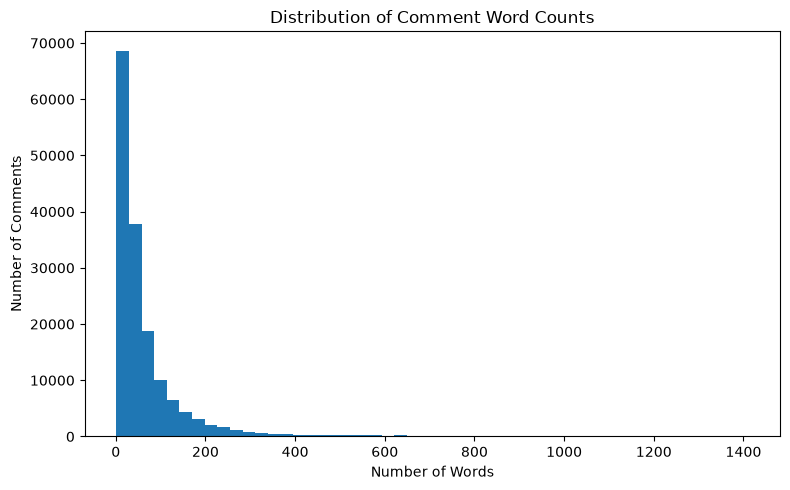

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['word_count'], bins=50)
plt.title("Distribution of Comment Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

## Compare lengths of toxic and non-toxic comments

In [23]:
df['has_toxic_label']=(y.sum(axis=1)>0)
df.groupby('has_toxic_label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
has_toxic_label,,,,,,,,
False,143346.0,68.921065,98.195083,1.0,18.0,38.0,78.0,1250.0
True,16225.0,52.717720,106.854731,2.0,11.0,23.0,50.0,1411.0


## Handle missing text

In [24]:
print(df["comment_text"].isnull().sum())

0


## Prepare a basic text-cleaning function

In [25]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

In [26]:
X_clean = X.apply(clean_text)

X_clean.head()

0    explanation why the edits made under my userna...
1    d'aww! he matches this background colour i'm s...
2    hey man, i'm really not trying to edit war. it...
3    " more i can't make any real suggestions on im...
4    you, sir, are my hero. any chance you remember...
Name: comment_text, dtype: str

This converts text to lowercase, normalizes repeated whitespace, and removes leading/trailing spaces.

We're deliberately not removing punctuation or stop words yet. Words such as "you", "are", and punctuation can sometimes carry useful context for toxicity detection. We can experiment with more extensive cleaning later.

# Train-test split

## Split the data

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X_clean, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training samples: 127656
Testing samples: 31915
Training target shape: (127656, 6)
Testing target shape: (31915, 6)


In ordinary single-label classification, we often use stratify=y to preserve class proportions. Here, each comment has six labels, and some combinations may be rare. We won't pass the entire multi-column y to ordinary stratify, because that can fail when some label combinations have too few examples.

For our initial baseline, we'll use a reproducible random split. Later, we can discuss iterative stratification, which is designed to preserve multi-label distributions more carefully.

In [28]:
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


# TF-IDF

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf = TfidfVectorizer()

In [31]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (127656, 165785)
Testing shape: (31915, 165785)


## See the vocabulary

In [33]:
print(len(tfidf.vocabulary_))

165785


In [34]:
print(list(tfidf.vocabulary_.items())[:20])

[('grandma', 64604), ('terri', 144103), ('should', 132284), ('burn', 27803), ('in', 73680), ('trash', 148068), ('is', 76943), ('hate', 67632), ('her', 68668), ('to', 146631), ('hell', 68399), ('71', 6857), ('74', 6954), ('76', 7032), ('40', 5193), ('may', 92499), ('2009', 2773), ('utc', 153168), ('it', 77311), ('would', 160574)]


In [39]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 165785)>
  Coords	Values
  (0, 64604)	0.6354351137360599
  (0, 144103)	0.5903394834391763
  (0, 132284)	0.0641219733550259
  (0, 27803)	0.15791403543877752
  (0, 73680)	0.03936618086035522
  (0, 148068)	0.32063614689207104
  (0, 76943)	0.036198030973445115
  (0, 67632)	0.12080238515765755
  (0, 68668)	0.09815467610009292
  (0, 146631)	0.030835935680660877
  (0, 68399)	0.11940003147633074
  (0, 6857)	0.13384969350017153
  (0, 6954)	0.1451122224880219
  (0, 7032)	0.13433054315334111
  (0, 5193)	0.12865743895130177


# Train multi label Logisitic Regression model

We'll use One-vs-Rest (OvR) classification to handle the six labels.

## Understanding how the model works

A normal Logistic Regression classifier predicts one binary outcome. For this project, we'll train six binary classifiers: Toxic Classifier, Severe toxic Classifier, Obscene Classifier, Threat Classifier, Insult Classifier, Identity hate classifier.

Each classifier learns to predict one particular label. All six classifiers receive the same comment features, but each learns a different target.

For example, one classifier learns whether a comment is toxic, while another learns whether it contains a threat.

This is called One-vs-Rest because each classifier treats its own label as the positive class and the absence of that label as the negative class.

## Train the model

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [42]:
model=OneVsRestClassifier(LogisticRegression(max_iter=1000))

Here Logistic Regression creates the binary Logistic Regression classifier. OneVsRestClassifier handles the six target columns by fitting a separate classifier for each label. max_iter=1000 allows the Logistic Regression optimization process more iterations to converge.

In [43]:
model.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

## Prediction

In [45]:
y_pred=model.predict(X_test_tfidf)

In [46]:
print("Prediction shape:", y_pred.shape)
print("Actual Shape:", y_test.shape)

Prediction shape: (31915, 6)
Actual Shape: (31915, 6)


In [51]:
y_test.iloc[0]

toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
Name: 119105, dtype: int64

In [52]:
y_pred[0]

array([0, 0, 0, 0, 0, 0])

In [53]:
y_pred_df=pd.DataFrame(y_pred, columns=label_columns, index=y_test.index)

print("Actual labels:")
display(y_test.head())

print("Predicted labels:")
display(y_pred_df.head())

Actual labels:


,toxic,severe_toxic,obscene,threat,insult,identity_hate
119105,0,0,0,0,0,0
131631,0,0,0,0,0,0
125326,0,0,0,0,0,0
111256,0,0,0,0,0,0
83590,0,0,0,0,0,0


Predicted labels:


,toxic,severe_toxic,obscene,threat,insult,identity_hate
119105,0,0,0,0,0,0
131631,0,0,0,0,0,0
125326,0,0,0,0,0,0
111256,0,0,0,0,0,0
83590,0,0,0,0,0,0


# Model Evaluation

We have six labels this means we need to evaluate the model for each label, rather than treating every comment as belonging to just one class.

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=label_columns, zero_division=0))

               precision    recall  f1-score   support

        toxic       0.91      0.61      0.73      3056
 severe_toxic       0.60      0.25      0.36       321
      obscene       0.92      0.62      0.74      1715
       threat       0.53      0.14      0.22        74
       insult       0.83      0.51      0.63      1614
identity_hate       0.74      0.14      0.24       294

    micro avg       0.88      0.55      0.68      7074
    macro avg       0.76      0.38      0.49      7074
 weighted avg       0.87      0.55      0.67      7074
  samples avg       0.06      0.05      0.05      7074



Look at the support column:

toxic: 3,056 positive examples

obscene: 1,715 positive examples

threat: only 74 positive examples

identity_hate: 294 positive examples

The less frequent labels have fewer positive training examples available. This is a sign of class imbalance, which can make it harder for the model to learn those labels reliably.

However, imbalance is not necessarily the only reason for the lower scores. The wording of comments and overlap between categories can also affect performance.

**What do the average scores tell us?**

**Micro F1** = 0.68: summarizes performance across all label decisions, giving more influence to labels with more positive examples.

**Macro F1** = 0.49: gives each label equal weight, so the weaker performance on rare labels matters more.

**Weighted F1** = 0.67: weights each label according to its support.

**Samples F1** = 0.05: measures performance per comment and then averages. This unusually low value is worth checking, especially alongside the other averages.

One thing to notice: the report shows 7074 as the support for the averages, which is the sum of the per-label supports. Since the samples average normally relates to individual comments, we should verify the shapes and data alignment before interpreting that particular score.

In [55]:
# Count positive and negative examples for each label
label_distribution = pd.DataFrame({
    "positive": y_train.sum(),
    "negative": len(y_train) - y_train.sum()
})

label_distribution["positive_percentage"] = (
    label_distribution["positive"] / len(y_train) * 100
)

display(label_distribution)

,positive,negative,positive_percentage
toxic,12238,115418,9.586702
severe_toxic,1274,126382,0.997995
obscene,6734,120922,5.275114
threat,404,127252,0.316476
insult,6263,121393,4.906154
identity_hate,1111,126545,0.870308


Our dataset is strongly imbalanced. For every label, negative examples greatly outnumber positive examples.

One way to address imbalance is to tell Logistic Regression to give more weight to mistakes involving the minority class.

Scikit-learn supports this through class_weight="balanced". With OneVsRestClassifier, each label gets its own binary classifier, so the weighting is calculated separately for each label.

## Train a class-weighted model

In [56]:
weighted_model=OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))

weighted_model.fit(X_train_tfidf, y_train)

y_pred_weighted=weighted_model.predict(X_test_tfidf)

In [57]:
print(classification_report(y_test, y_pred_weighted, target_names=label_columns, zero_division=0))

               precision    recall  f1-score   support

        toxic       0.64      0.87      0.74      3056
 severe_toxic       0.27      0.82      0.40       321
      obscene       0.69      0.89      0.78      1715
       threat       0.17      0.77      0.28        74
       insult       0.56      0.87      0.68      1614
identity_hate       0.25      0.75      0.38       294

    micro avg       0.56      0.87      0.68      7074
    macro avg       0.43      0.83      0.54      7074
 weighted avg       0.60      0.87      0.70      7074
  samples avg       0.06      0.08      0.07      7074



In [70]:
from sklearn.metrics import confusion_matrix

j=0
confusion_matrices = {}
for i in y_test.columns:
    print('Confusion Matrix for', i)
    cm=confusion_matrix(y_test[i], y_pred_weighted[:,j])
    confusion_matrices[i] = cm
    j+=1
    print(cm)

Confusion Matrix for toxic
[[27369  1490]
 [  397  2659]]
Confusion Matrix for severe_toxic
[[30880   714]
 [   59   262]]
Confusion Matrix for obscene
[[29531   669]
 [  192  1523]]
Confusion Matrix for threat
[[31571   270]
 [   17    57]]
Confusion Matrix for insult
[[29196  1105]
 [  207  1407]]
Confusion Matrix for identity_hate
[[30970   651]
 [   73   221]]


## Confusion Matrix Analysis

Since this is a **multi-label classification** problem, a separate confusion matrix is generated for each toxicity label. Each confusion matrix contains four types of predictions:

* **True Negative (TN):** The comment does not have the label and the model correctly predicts it as negative.
* **False Positive (FP):** The comment does not have the label, but the model incorrectly predicts it as positive.
* **False Negative (FN):** The comment has the label, but the model fails to detect it.
* **True Positive (TP):** The comment has the label and the model correctly detects it.

The confusion matrices obtained from the class-weighted Logistic Regression model are:

### Toxic

```text
[[27369  1490]
 [  397  2659]]
```

The model correctly identified **2,659 toxic comments (TP)** and missed **397 toxic comments (FN)**. It also incorrectly flagged **1,490 non-toxic comments as toxic (FP)**.

This shows that the model has high recall for the `toxic` label because it successfully detects most of the actual toxic comments. However, the relatively large number of false positives reduces precision.

### Severe Toxic

```text
[[30880   714]
 [   59   262]]
```

The model correctly detected **262 severe-toxic comments**, while missing **59**. However, it incorrectly classified **714 non-severe-toxic comments as severe-toxic**.

This explains the high recall of **0.82** but relatively low precision of **0.27**. The model is effective at finding severe-toxic comments, but many of its positive predictions are false positives.

### Obscene

```text
[[29531   669]
 [  192  1523]]
```

The model correctly detected **1,523 obscene comments** and missed **192**. There were **669 false positives**.

Compared with the other labels, `obscene` has a relatively good balance between precision and recall, resulting in an F1-score of **0.78**.

### Threat

```text
[[31571  270]
 [   17   57]]
```

The model detected **57 out of 74 actual threat comments**, while missing **17**. However, it incorrectly classified **270 non-threat comments as threats**.

This is a clear example of the **precision-recall trade-off**. The recall is high at **0.77**, meaning most actual threats were detected, but precision is only **0.17** because there are many false-positive predictions.

### Insult

```text
[[29196  1105]
 [  207  1407]]
```

The model correctly detected **1,407 insult comments** and missed **207**. It also generated **1,105 false positives**.

The resulting recall of **0.87** shows that the model detects most actual insults, while the precision of **0.56** indicates that a considerable number of its positive predictions are incorrect.

### Identity Hate

```text
[[30970  651]
 [  73  221]]
```

The model correctly detected **221 identity-hate comments** and missed **73**, while generating **651 false positives**.

Again, the model has high recall (**0.75**) but relatively low precision (**0.25**). This is related to the strong class imbalance, since identity-hate comments are much less frequent than negative examples.

## Overall Observation

The confusion matrices clearly demonstrate the effect of using `class_weight="balanced"`.

The class-weighted model became much more sensitive to the minority positive classes. As a result, **false negatives decreased and recall increased substantially**. For example, recall for `threat` increased from **0.14 to 0.77**, while recall for `identity_hate` increased from **0.14 to 0.75**.

However, this improvement in recall came with an increase in **false positives**, which caused precision to decrease. Therefore, the model may identify more genuinely toxic comments, but it may also incorrectly flag a larger number of non-toxic comments.

This creates an important **precision-recall trade-off** for a real-world toxicity detection system. If the system is used only to identify potentially harmful comments for further review, high recall can be useful because fewer toxic comments are missed. However, if predictions are used to automatically delete comments, suspend users, or apply penalties, false positives become more important because incorrectly flagging legitimate comments can have undesirable consequences.

Therefore, the model should not be evaluated using a single metric alone. **Precision, recall, F1-score, and the confusion matrices should be considered together**, depending on how the toxicity detection system will be used.

For this project, the class-weighted model demonstrates that addressing class imbalance can substantially improve the detection of minority toxicity categories, but it also shows why improving recall does not necessarily mean that the model is suitable for automatic moderation without considering false positives.


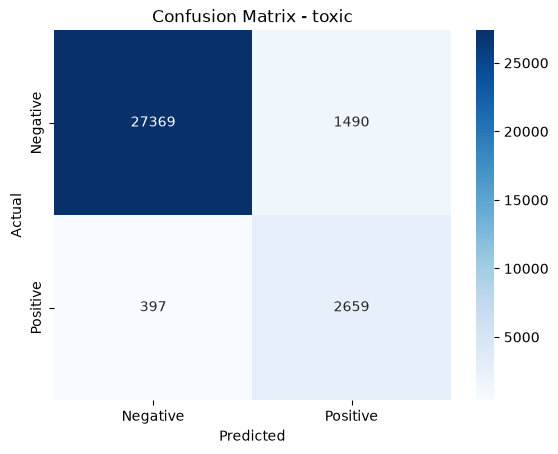

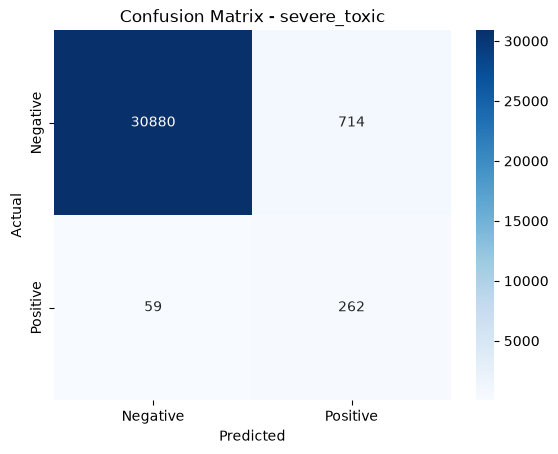

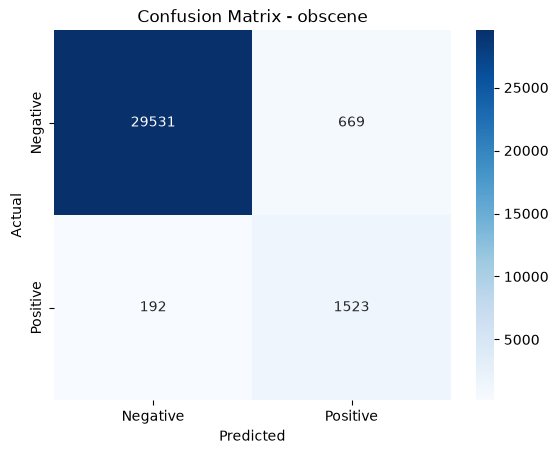

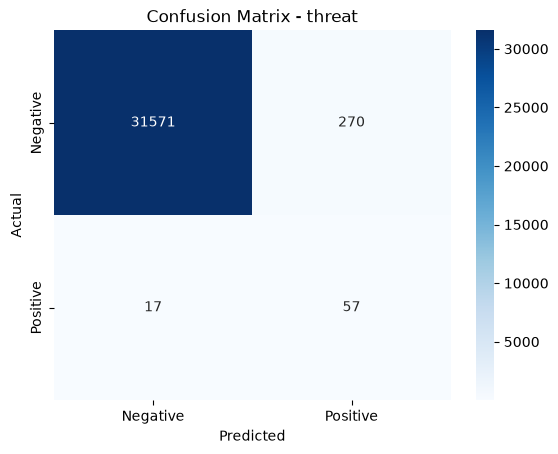

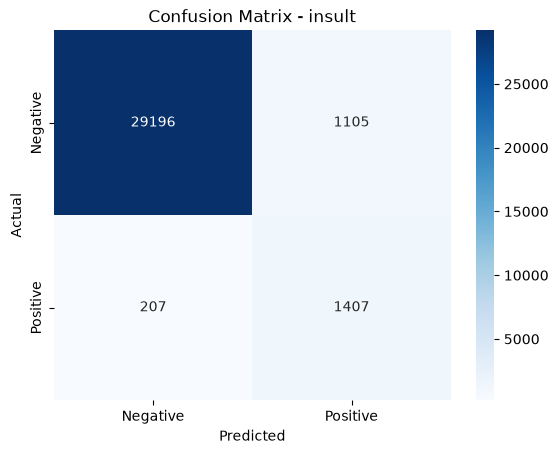

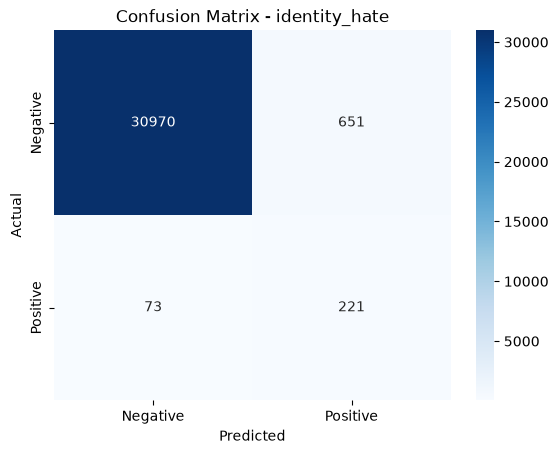

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

for label in label_columns:
    cm = confusion_matrices[label]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {label}")
    plt.show()

# Threshold Tuning with ROC AUC curves

In [74]:
y_prob=weighted_model.predict_proba(X_test_tfidf)

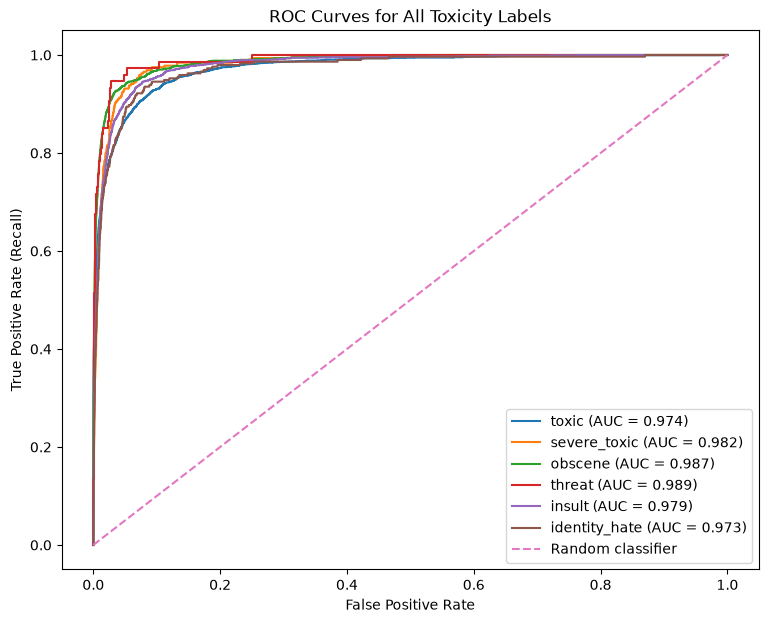

In [75]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for i, label in enumerate(label_columns):
    fpr, tpr, thresholds = roc_curve(
        y_test[label],
        y_prob[:, i]
    )
    
    auc = roc_auc_score(
        y_test[label],
        y_prob[:, i]
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC = {auc:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves for All Toxicity Labels")
plt.legend()
plt.show()

# Threshold Tuning with ROC Curve and AUC

## Threshold Tuning

A classification model usually produces a probability or confidence score for each class. A **threshold** is used to convert this probability into a final class prediction.

For example, with a threshold of 0.5:

* Probability ≥ 0.5 → Positive
* Probability < 0.5 → Negative

The default threshold of 0.5 is not always optimal. **Threshold tuning** involves changing this value to achieve a desired balance between precision and recall.

### Effect of Changing the Threshold

* **Lower threshold:** More instances are classified as positive, increasing recall but potentially increasing false positives and reducing precision.
* **Higher threshold:** Fewer instances are classified as positive, increasing precision but potentially increasing false negatives and reducing recall.

Therefore, the appropriate threshold depends on the purpose of the classification system.

## ROC Curve

The **Receiver Operating Characteristic (ROC) curve** shows how the model's performance changes across different classification thresholds.

It plots:

* **True Positive Rate (TPR):** The proportion of actual positive samples correctly identified. It is also known as **Recall**.
* **False Positive Rate (FPR):** The proportion of actual negative samples incorrectly classified as positive.

The ROC curve allows us to observe the trade-off between detecting positive samples and generating false positives at different thresholds.

## AUC

**AUC (Area Under the ROC Curve)** represents the overall area under the ROC curve and measures how well the model separates positive and negative samples across different thresholds.

* **AUC = 1.0:** Perfect separation
* **AUC ≈ 0.5:** Performance similar to random classification
* **Higher AUC:** Better ability to distinguish between positive and negative samples

AUC evaluates the model across **many possible thresholds**, rather than evaluating it at only one threshold.

## Relationship Between ROC, AUC, and Threshold Tuning

The ROC curve provides information about model performance at different thresholds, while AUC summarizes the overall discrimination ability of the model.

A high AUC indicates that the model can generally rank positive samples above negative samples effectively. However, it does not mean that a particular threshold, such as 0.5, will provide the best precision, recall, or F1-score.

Therefore, even a model with a high AUC may require **threshold tuning** to obtain suitable classification results.

## Threshold Selection in Toxic Comment Classification

In toxic comment classification, threshold selection is particularly important because the consequences of false positives and false negatives can differ.

A **lower threshold** may identify more toxic comments, resulting in higher recall, but it can also incorrectly flag more non-toxic comments.

A **higher threshold** may reduce false positives and improve precision, but some toxic comments may be missed.

Thus, the threshold should be selected according to the intended use of the system, such as assisting human moderators or automatically filtering comments.

## Conclusion

Threshold tuning allows a classification model to adjust its predictions according to the desired precision-recall trade-off. The ROC curve helps visualize this trade-off across different thresholds, while AUC provides an overall measure of the model's ability to distinguish between positive and negative classes.

For highly imbalanced datasets such as the Jigsaw Toxic Comment dataset, **Precision-Recall curves should also be considered**, especially for rare toxicity categories.


# Precision–Recall Curve

Since our Jigsaw dataset is highly imbalanced, the next step is to examine the Precision–Recall (PR) curve.

The ROC curve looked at the trade-off between TPR and FPR, while the PR curve focuses directly on precision and recall. This makes it particularly useful when positive classes are rare, such as threat, identity_hate, and severe_toxic.

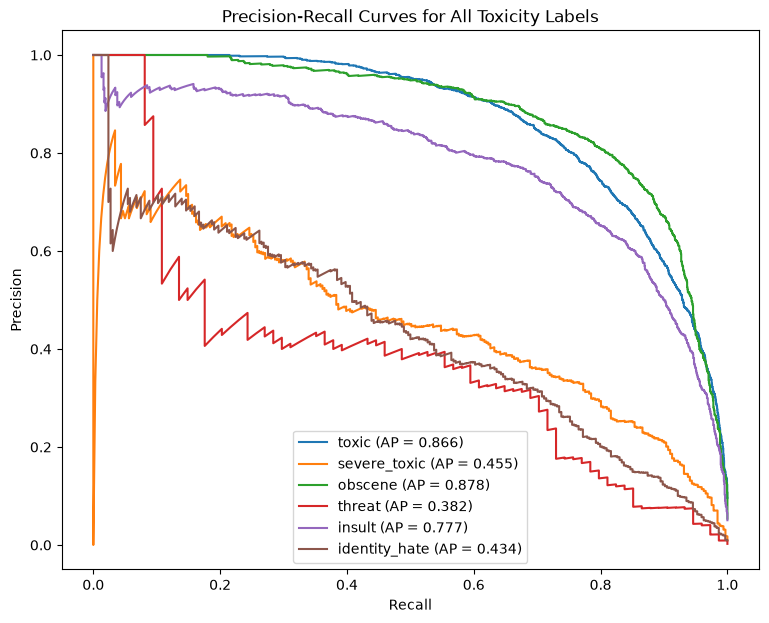

In [76]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for i, label in enumerate(label_columns):
    precision, recall, thresholds = precision_recall_curve(
        y_test[label],
        y_prob[:, i]
    )
    
    ap = average_precision_score(
        y_test[label],
        y_prob[:, i]
    )
    
    plt.plot(
        recall,
        precision,
        label=f"{label} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Toxicity Labels")
plt.legend()
plt.show()

In [77]:
for i, label in enumerate(label_columns):
    ap = average_precision_score(
        y_test[label],
        y_prob[:, i]
    )
    print(f"{label}: AP = {ap:.3f}")

toxic: AP = 0.866
severe_toxic: AP = 0.455
obscene: AP = 0.878
threat: AP = 0.382
insult: AP = 0.777
identity_hate: AP = 0.434


# Precision-Recall Curve and Average Precision

## Precision-Recall Curve

The **Precision-Recall (PR) curve** shows the relationship between **precision** and **recall** at different classification thresholds.

* **Precision:** Proportion of predicted positive samples that are actually positive.
* **Recall:** Proportion of actual positive samples that are correctly identified.

The PR curve helps us understand how changing the classification threshold affects the balance between precision and recall.

### Effect of Threshold

When the threshold is **lower**:

* More samples are classified as positive.
* Recall generally increases.
* More false positives may occur.
* Precision may decrease.

When the threshold is **higher**:

* Fewer samples are classified as positive.
* Precision may increase.
* False positives may decrease.
* Recall may decrease.

Therefore, there is usually a trade-off between precision and recall.

## Average Precision (AP)

**Average Precision (AP)** summarizes the Precision-Recall curve into a single value.

A higher AP indicates that the model maintains a better balance between precision and recall across different thresholds.

AP is particularly useful for **imbalanced classification problems**, where the positive class may be much smaller than the negative class.

## Results

The Average Precision values obtained from the model are:

| Label         | Average Precision |
| ------------- | ----------------: |
| Toxic         |             0.866 |
| Severe Toxic  |             0.455 |
| Obscene       |             0.878 |
| Threat        |             0.382 |
| Insult        |             0.777 |
| Identity Hate |             0.434 |

### Interpretation

The model performs relatively strongly for **toxic**, **obscene**, and **insult** comments, with AP values of 0.866, 0.878, and 0.777 respectively.

The lower AP values for **severe toxic**, **threat**, and **identity hate** indicate that maintaining both high precision and high recall is more difficult for these categories.

This is consistent with the class imbalance observed during EDA, where these labels had considerably fewer positive samples.

## ROC AUC vs Average Precision

ROC AUC and AP measure different aspects of model performance.

* **ROC AUC** evaluates how well the model separates positive and negative samples across different thresholds.
* **Average Precision** focuses on the relationship between precision and recall across different thresholds.

For highly imbalanced datasets, AP can provide a more informative view of performance on the positive class.

For example, the `threat` label had a very high **ROC AUC of 0.989**, but its **AP was only 0.382**. This shows that a high ROC AUC does not necessarily mean that the model will maintain high precision and recall at practical classification thresholds.

## Conclusion

The Precision-Recall curve provides a useful way to evaluate the model under different classification thresholds. Average Precision summarizes this behavior into a single metric.

Since the Jigsaw dataset is highly imbalanced, especially for rare toxicity categories, Precision-Recall analysis is important before selecting the final classification thresholds.


# Threshold Selection

In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for i, label in enumerate(label_columns):
    for threshold in thresholds:
        
        y_pred_threshold = (y_prob[:, i] >= threshold).astype(int)
        
        precision = precision_score(
            y_test[label],
            y_pred_threshold,
            zero_division=0
        )
        
        recall = recall_score(
            y_test[label],
            y_pred_threshold,
            zero_division=0
        )
        
        f1 = f1_score(
            y_test[label],
            y_pred_threshold,
            zero_division=0
        )
        
        results.append({
            "label": label,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

threshold_results = pd.DataFrame(results)

threshold_results.head(10)

,label,threshold,precision,recall,f1
0,toxic,0.1,0.231052,0.988547,0.374558
1,toxic,0.2,0.360141,0.968586,0.525055
2,toxic,0.3,0.468293,0.942408,0.625679
3,toxic,0.4,0.561613,0.906741,0.693617
4,toxic,0.5,0.640877,0.870092,0.738099
5,toxic,0.6,0.712745,0.821662,0.763338
6,toxic,0.7,0.779980,0.772579,0.776262
7,toxic,0.8,0.847404,0.699607,0.766446
8,toxic,0.9,0.910793,0.604712,0.726844
9,severe_toxic,0.1,0.131590,0.940810,0.230887


In [80]:
best_thresholds = (
    threshold_results
    .loc[
        threshold_results.groupby("label")["f1"].idxmax()
    ]
    .reset_index(drop=True)
)

best_thresholds

,label,threshold,precision,recall,f1
0,identity_hate,0.9,0.449367,0.482993,0.465574
1,insult,0.8,0.720097,0.734820,0.727384
2,obscene,0.7,0.795918,0.818659,0.807128
3,severe_toxic,0.9,0.406061,0.626168,0.492647
4,threat,0.8,0.324324,0.648649,0.432432
5,toxic,0.7,0.779980,0.772579,0.776262


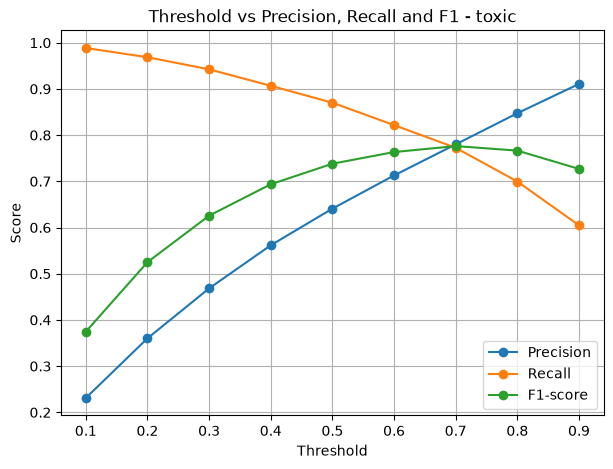

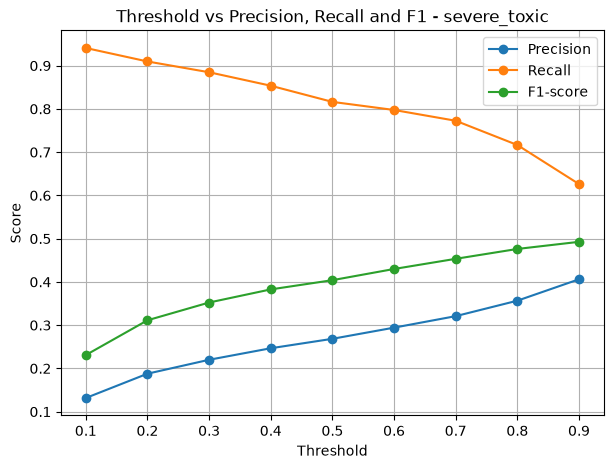

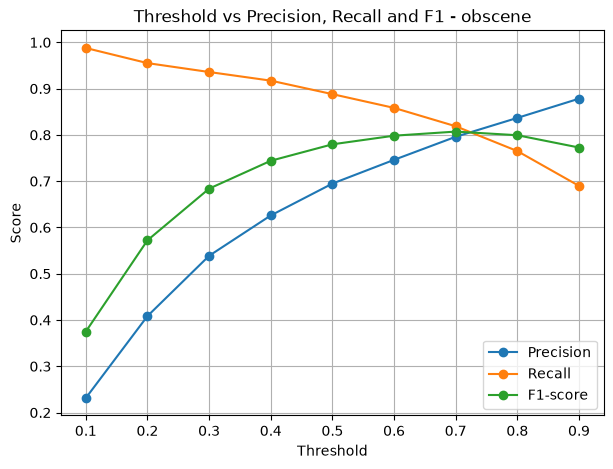

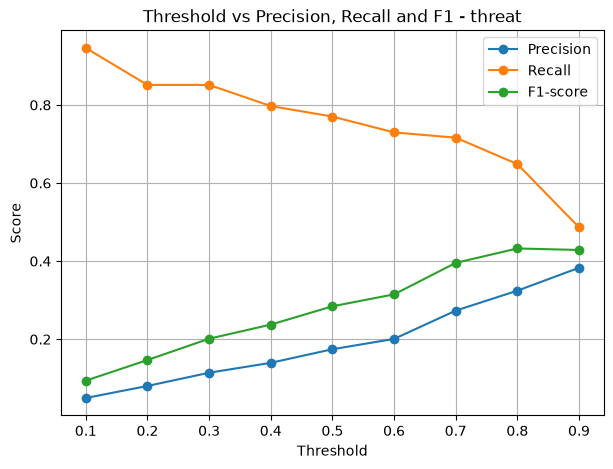

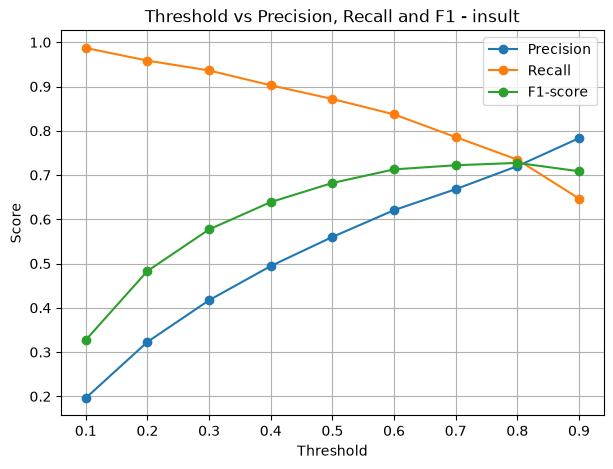

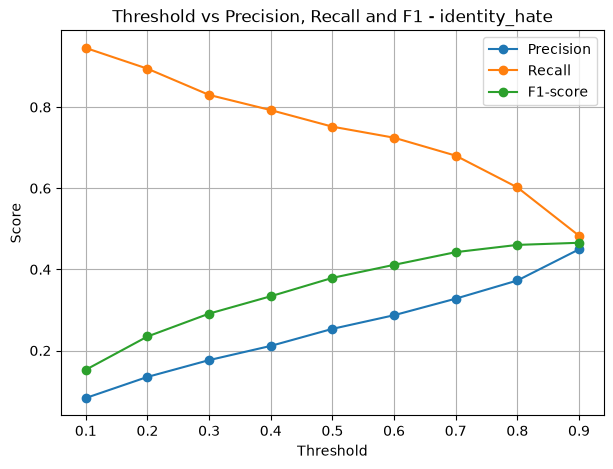

In [81]:
import matplotlib.pyplot as plt

for label in label_columns:
    
    data = threshold_results[
        threshold_results["label"] == label
    ]
    
    plt.figure(figsize=(7, 5))
    
    plt.plot(
        data["threshold"],
        data["precision"],
        marker="o",
        label="Precision"
    )
    
    plt.plot(
        data["threshold"],
        data["recall"],
        marker="o",
        label="Recall"
    )
    
    plt.plot(
        data["threshold"],
        data["f1"],
        marker="o",
        label="F1-score"
    )
    
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold vs Precision, Recall and F1 - {label}")
    plt.legend()
    plt.grid()
    plt.show()

In [82]:
tuned_thresholds = {
    "toxic": 0.7,
    "severe_toxic": 0.9,
    "obscene": 0.7,
    "threat": 0.8,
    "insult": 0.8,
    "identity_hate": 0.9
}

y_pred_tuned = np.zeros_like(y_test.values)

for i, label in enumerate(label_columns):
    y_pred_tuned[:, i] = (
        y_prob[:, i] >= tuned_thresholds[label]
    ).astype(int)

print("Default Threshold (0.5)")
print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=label_columns,
    zero_division=0
))

print("\nTuned Thresholds")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=label_columns,
    zero_division=0
))

Default Threshold (0.5)
               precision    recall  f1-score   support

        toxic       0.64      0.87      0.74      3056
 severe_toxic       0.27      0.82      0.40       321
      obscene       0.69      0.89      0.78      1715
       threat       0.17      0.77      0.28        74
       insult       0.56      0.87      0.68      1614
identity_hate       0.25      0.75      0.38       294

    micro avg       0.56      0.87      0.68      7074
    macro avg       0.43      0.83      0.54      7074
 weighted avg       0.60      0.87      0.70      7074
  samples avg       0.06      0.08      0.07      7074


Tuned Thresholds
               precision    recall  f1-score   support

        toxic       0.78      0.77      0.78      3056
 severe_toxic       0.41      0.63      0.49       321
      obscene       0.80      0.82      0.81      1715
       threat       0.32      0.65      0.43        74
       insult       0.72      0.73      0.73      1614
identity_hate      

# Threshold Selection and Comparison

## Threshold Selection

A classification model produces a probability for each toxicity label. The probability must be converted into a binary prediction using a **classification threshold**.

The default threshold is usually **0.5**, but this may not provide the desired balance between precision and recall.

Based on the threshold analysis, different thresholds were selected for each toxicity label:

| Label         | Selected Threshold |
| ------------- | -----------------: |
| Toxic         |                0.7 |
| Severe Toxic  |                0.9 |
| Obscene       |                0.7 |
| Threat        |                0.8 |
| Insult        |                0.8 |
| Identity Hate |                0.9 |

These thresholds were selected based on the **F1-score**, which balances precision and recall.

## Default vs Tuned Thresholds

The model was evaluated using both the default threshold of 0.5 and the selected thresholds.

| Metric          | Default Threshold | Tuned Threshold |
| --------------- | ----------------: | --------------: |
| Micro Precision |              0.56 |        **0.72** |
| Micro Recall    |          **0.87** |            0.76 |
| Micro F1        |              0.68 |        **0.74** |
| Macro Precision |              0.43 |        **0.58** |
| Macro Recall    |          **0.83** |            0.68 |
| Macro F1        |              0.54 |        **0.62** |
| Weighted F1     |              0.70 |        **0.74** |

## Interpretation

Using the default threshold of 0.5 resulted in **high recall but relatively low precision**. The model detected a large proportion of the actual positive labels, but it also produced more false positives.

After threshold tuning, **precision increased while recall decreased**. This is expected because increasing the threshold makes the model more selective when assigning a positive label.

The overall F1-score improved:

* Micro F1: **0.68 → 0.74**
* Macro F1: **0.54 → 0.62**
* Weighted F1: **0.70 → 0.74**

This indicates a better balance between precision and recall after threshold tuning.

## Per-Label Results

The F1-score also improved for every toxicity category:

| Label         | F1 at 0.5 | F1 after Tuning |
| ------------- | --------: | --------------: |
| Toxic         |      0.74 |        **0.78** |
| Severe Toxic  |      0.40 |        **0.49** |
| Obscene       |      0.78 |        **0.81** |
| Threat        |      0.28 |        **0.43** |
| Insult        |      0.68 |        **0.73** |
| Identity Hate |      0.38 |        **0.47** |

The largest improvement was observed for the `threat` category, where F1 increased from **0.28 to 0.43**.

## Conclusion

Threshold tuning improved the balance between precision and recall without changing the underlying model. Instead, it changed how the model's probability outputs were converted into final predictions.

The results demonstrate that in a **multi-label classification problem**, using a separate threshold for each label can provide better performance than applying the same default threshold of 0.5 to every label.

The selected thresholds are based on F1-score and should ultimately be adjusted according to the intended application and the relative importance of false positives and false negatives.


# Final Multi-Label Evaluation Metrics

Since the Jigsaw Toxic Comment Classification problem is a **multi-label classification problem**, a single comment can belong to multiple toxicity categories at the same time.

For example, a comment may be classified as:

```text
Toxic = 1
Obscene = 1
Insult = 1
```

Therefore, in addition to evaluating each label individually, we use metrics that evaluate the model's **overall multi-label predictions**.

## 1. Hamming Loss

**Hamming Loss** measures the fraction of individual labels that are incorrectly predicted.

For every comment, the model makes six binary predictions. Hamming Loss checks each of these predictions independently.

$$
Hamming\ Loss =
\frac{\text{Number of incorrectly predicted labels}}
{\text{Total number of labels}}
$$

### Interpretation

* **Lower Hamming Loss → Better performance**
* A Hamming Loss of **0** means every individual label was predicted correctly.
* Unlike subset accuracy, one incorrect label does not make the entire sample incorrect.

For example, if the actual labels are:

```text
[1, 1, 0, 0, 0, 0]
```

and the prediction is:

```text
[1, 0, 0, 0, 0, 0]
```

only one of the six labels is incorrect.

## 2. Jaccard Score

The **Jaccard Score** measures how much the predicted set of labels overlaps with the actual set of labels.

$$
Jaccard =
\frac{|True\ Labels \cap Predicted\ Labels|}
{|True\ Labels \cup Predicted\ Labels|}
$$

### Example

Suppose the actual labels are:

```text
Actual:
[toxic, insult]
```

and the model predicts:

```text
Predicted:
[toxic, obscene]
```

The intersection is:

```text
[toxic]
```

The union is:

```text
[toxic, insult, obscene]
```

Therefore:

$$
Jaccard = \frac{1}{3} = 0.33
$$

### Interpretation

* **Higher Jaccard Score → Better performance**
* **1.0** means the predicted labels exactly match the actual labels.
* **0.0** means there is no overlap between the predicted and actual labels.

Jaccard is useful because it evaluates how well the model predicts the **combination of labels** for each comment.

## 3. Subset Accuracy

**Subset Accuracy** measures the percentage of samples for which **all labels are predicted correctly**.

It is one of the strictest multi-label metrics.

For example:

```text
Actual:
[toxic, insult, obscene]

Predicted:
[toxic, insult, obscene]
```

The prediction is completely correct.

However:

```text
Actual:
[toxic, insult, obscene]

Predicted:
[toxic, insult]
```

The prediction is considered **incorrect**, even though two out of three labels were correct.

### Interpretation

* **Higher Subset Accuracy → Better performance**
* **1.0** means every sample has exactly the correct set of labels.
* A single incorrect label causes the entire sample to be counted as incorrect.

## Comparison of the Metrics

| Metric          | What it measures                                | Better value |
| --------------- | ----------------------------------------------- | ------------ |
| Hamming Loss    | Individual label errors                         | Lower        |
| Jaccard Score   | Overlap between actual and predicted label sets | Higher       |
| Subset Accuracy | Exact match of the complete label set           | Higher       |

## Why Use All Three?

Each metric provides a different perspective.

**Hamming Loss** tells us how many individual label predictions are wrong.

**Jaccard Score** tells us how closely the predicted label sets match the actual label sets.

**Subset Accuracy** tells us how often the model gets the **entire set of labels exactly right**.

Using these metrics together provides a more complete evaluation of a multi-label toxicity classification model.

## Important Note

Subset Accuracy can be quite low even when the model has reasonable individual-label performance because it requires **every label for a sample to be correct**.

Therefore, it should not be interpreted alone. Hamming Loss, Jaccard Score, precision, recall, and F1-score should be considered together when evaluating the final model.


## Hamming Loss

In [83]:
from sklearn.metrics import hamming_loss

hamming=hamming_loss(y_test, y_pred_tuned)
print("Hamming Loss:", hamming)

Hamming Loss: 0.019776489633923443


## Jaccard Score

In [88]:
from sklearn.metrics import jaccard_score

jaccard_micro = jaccard_score(
    y_test,
    y_pred_tuned,
    average="micro",
    zero_division=0
)

jaccard_macro = jaccard_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)

print("Micro Jaccard:", jaccard_micro)
print("Macro Jaccard:", jaccard_macro)

Micro Jaccard: 0.5851681454704787
Macro Jaccard: 0.46477321500876373


## Subset Accuracy

In [86]:
from sklearn.metrics import accuracy_score

subset_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Subset Accuracy:", subset_accuracy)

Subset Accuracy: 0.910637631207896


# Interpretation of Final Multi-Label Evaluation

The final model was evaluated using multiple metrics because the Jigsaw Toxic Comment Classification problem is a **multi-label classification problem**. A comment can belong to multiple toxicity categories simultaneously.

## Final Evaluation Results

| Metric              |  Score |
| ------------------- | -----: |
| Micro F1-score      |  0.740 |
| Macro F1-score      |  0.620 |
| Weighted F1-score   |  0.740 |
| Micro Jaccard Score |  0.585 |
| Macro Jaccard Score |  0.465 |
| Hamming Loss        | 0.0198 |
| Subset Accuracy     |  0.911 |

The model also achieved high ROC-AUC values across the six toxicity categories, ranging from approximately **0.973 to 0.989**. Average Precision values ranged from **0.382 to 0.878**.

## Hamming Loss

The Hamming Loss of **0.0198** indicates that approximately **1.98% of individual label predictions were incorrect**.

A lower Hamming Loss indicates better performance. The low value suggests that the model makes relatively few errors when each toxicity label is considered independently.

## Jaccard Score

The **Micro Jaccard Score of 0.585** indicates a moderate overlap between the actual and predicted positive labels when all labels are considered together.

The **Macro Jaccard Score of 0.465** is lower because it gives equal importance to every toxicity category. Therefore, categories with weaker performance, particularly the rarer labels, have a greater influence on the macro score.

The difference between micro and macro Jaccard also reflects the effect of **class imbalance** in the dataset.

## Subset Accuracy

The Subset Accuracy of **0.911** means that approximately **91.1% of test samples had an exact match between their complete actual and predicted label sets**.

However, subset accuracy is a strict metric because every label for a sample must be correct.

It should also be interpreted carefully in this dataset because a large proportion of comments are non-toxic. A comment with all six labels correctly predicted as zero counts as an exact match.

Therefore, a high subset accuracy does not necessarily mean that the model detects every toxicity category equally well.

## F1-score

The **Micro F1-score of 0.740** indicates good overall performance when individual label predictions are considered collectively.

The **Macro F1-score of 0.620** is lower because every toxicity category is given equal importance. This reflects the weaker performance on less frequent categories such as `threat`, `identity_hate`, and `severe_toxic`.

The **Weighted F1-score of 0.740** is similar to the Micro F1-score because the more frequent toxicity categories have greater influence on the weighted result.

## Overall Interpretation

The evaluation shows that the model performs relatively well on the more common toxicity categories but has greater difficulty with rare categories.

The threshold tuning improved the balance between precision and recall, increasing the Micro F1-score from **0.68 to 0.74** and the Macro F1-score from **0.54 to 0.62**.

The results also demonstrate why multiple evaluation metrics are necessary for a multi-label and imbalanced dataset. Hamming Loss evaluates individual label errors, Jaccard measures overlap between actual and predicted labels, Subset Accuracy evaluates exact label-set matches, and F1-score evaluates the balance between precision and recall.

Overall, The model achieves stronger performance on the more frequent toxicity categories, while performance is weaker on rare labels.


In [89]:
error_analysis = {}

for i, label in enumerate(label_columns):
    actual = y_test[label].values
    predicted = y_pred_tuned[:, i]
    probability = y_prob[:, i]

    false_positive_idx = np.where(
        (actual == 0) & (predicted == 1)
    )[0]

    false_negative_idx = np.where(
        (actual == 1) & (predicted == 0)
    )[0]

    error_analysis[label] = {
        "false_positive": false_positive_idx,
        "false_negative": false_negative_idx
    }

In [90]:
for label in label_columns:
    indices = error_analysis[label]["false_positive"]

    print(f"\n{'=' * 60}")
    print(f"FALSE POSITIVES - {label}")
    print(f"{'=' * 60}")

    for idx in indices[:5]:
        print(f"Probability: {y_prob[idx, label_columns.index(label)]:.3f}")
        print(f"Comment: {X_test.iloc[idx]}")
        print()


FALSE POSITIVES - toxic
Probability: 0.700
Comment: nice job so you just go around destroying other people's efforts of completing half-done wikipedia pages? go away.

Probability: 0.985
Comment: ram it up ur ass very hard till ur eyes water

Probability: 0.802
Comment: grafikm, please dont hurt your credibility by seconding insinuations and demands based on pure (ideological? ethnic?) hate. or are you deliberately adding fuel to the fire and beating the drums? that's not what wikipedia is about.

Probability: 0.724
Comment: " of course not. from sahih bukhari volume 3, book 34, number 351: http://www.usc.edu/org/cmje/religious-texts/hadith/bukhari/034-sbt.php#003.034.351 narrated jabir bin abdullah: a man decided that a slave of his would be manumitted after his death and later on he was in need of money, so the prophet took the slave and said, ""who will buy this slave from me?"" nu'aim bin 'abdullah bought him for such and such price and the prophet gave him the slave. you ready to

In [91]:
for label in label_columns:
    indices = error_analysis[label]["false_negative"]

    print(f"\n{'=' * 60}")
    print(f"FALSE NEGATIVES - {label}")
    print(f"{'=' * 60}")

    for idx in indices[:5]:
        print(f"Probability: {y_prob[idx, label_columns.index(label)]:.3f}")
        print(f"Comment: {X_test.iloc[idx]}")
        print()


FALSE NEGATIVES - toxic
Probability: 0.569
Comment: please do not write me more!! silly perhaps no one has told you but you're obviously frustrated and i would like that please do not write me more. for my part i have decided that i will not bring anything more to wikipedia, because wikipedia is a monopoly of information manipulated by a lot of abnormals like you.

Probability: 0.392
Comment: " sockpuppet? oh no stifle. just what do you think your doing? i've worked too hard for you to do this. and why? dont assume, look at my contributions and what have i done? what ties me to ""smugface"" (as you and every second person belives)? and what sets us apart? constructive edits! thats bloody what! remove or find an answer. not happy jan! could we not discuss this in the stead of dirtying up each others pages? your contribution patterns are very similar - very little article contributions, causing general annoyance, and yelling at anyone who tries to call you on it. "

Probability: 0.221
C

### Error Analysis

Error analysis was performed by examining false positives and false negatives for all six toxicity labels: toxic, severe toxic, obscene, threat, insult, and identity hate.

The analysis showed that the model frequently relies on lexical patterns such as profanity, insults, and aggressive expressions. However, it sometimes confuses related categories, such as general insults with obscene language or personal abuse with identity-based hate. It also struggles with contextual meaning, indirect hostility, quoted language, and unusual expressions.

The false negatives demonstrate that some comments receive relatively high predicted probabilities but remain below the selected classification thresholds. This highlights the importance of threshold selection in multi-label classification.

Overall, the analysis indicates that the TF-IDF and One-vs-Rest Logistic Regression model learns useful toxicity-related patterns but has limitations in contextual understanding and distinguishing closely related categories. These findings can guide future improvements, such as label-specific threshold selection, better text representations, and context-aware models.
